# Линейная алгебра, математический анализ

In [6]:
import sys
print(sys.executable)

d:\Workspace\otus.ru\ML\DZ\homework_08\.venv\Scripts\python.exe


In [ ]:
# Линейная алгебра. Задача №1.
# Проверка решения, см. *.pdf
import numpy as np
a = np.array([[2, 3,-1],[-4,5,0]])
b = np.array([[1,-3, 5],[2,-4, 2],[7, 0, 1]])
c = np.array([[6, 4, 8],[-3, -5, 1],[9, 2, 5]])
A = a.T
B = b.T
C = c.T

D1 = (A.T) @ C 
D2 =  2 * (A.T) @ (B.T)

Dr = D1 - D2
print("(A.T) @ C :")
print(D1)
print("")
print("2 * (A.T) @ (B.T)")
print(D2)
print("")
print("Результат:")
print(Dr)



In [ ]:
# Линейная алгебра, задачи 2,3,4 см. *.pdf

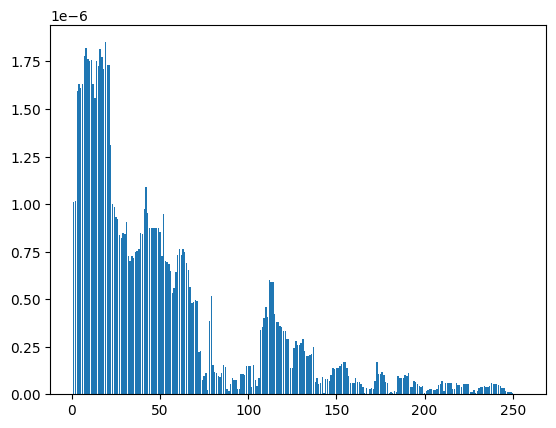

In [ ]:
# Линейная алгебра. Задача №5. Малоранговая аппроксимация матрицы.
# Алгоритм:
# 1. Создать матрицу
# 2. В цикле выполнить SVD для матрицы A (N x N) по рангу r с N до 1 
# 3. Построить график
import numpy as np
import matplotlib.pyplot as pl

N = 256
np.random.seed(42)
A = np.random.rand(N,N)

appr_func = dict()
# расчет ошибки апроксимации для A и A_apr c рангом r
def rmse_r (A,A_apr,r):
    rmse = np.sqrt(np.mean(A - A_apr) ** 2)
    return  r, rmse

# Вычисляет SVD для ранга r
def apr_matrix_r(A, r):
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    U_r = U[:, :r]
    s_r = s[:r]
    Vt_r = Vt[:r, :]
    # Аппроксимация матрицы для ранка r
    A_r = U_r @ np.diag(s_r) @ Vt_r
    return A_r

# Пошаговое уменьшение ранга от N до 1 и расчет rmse (корень из среднеквардатичной ошибки)
for r in range(N, 0, -1):
    Ar = apr_matrix_r(A, r)
    rmse = float(np.sqrt(np.mean(A - Ar) ** 2))
    appr_func[r] = rmse

#строим график
keys = list(appr_func.keys())
values = list(appr_func.values())
pl.bar(keys,values)
pl.show()

# Выводы по графику: 
## 1. Выбрать желаемый диапазон рангов для апроксимирующей матрицы.
## 2. В выбранном диапазоне рангов определить минимальное значение корня из среднеквардатичной ошибки (rmse) 